# Waste Type Identification — Selezione della ricetta su un probe *brief-matched*


## 1. Configurazione

Gli stessi percorsi e iperparametri del resto del progetto.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# Percorsi
BASE = Path('/content/drive/MyDrive/2026_MLinf_gr41/Waste-Project')
DRIVE_DATASET_DIR = BASE / 'dataset'
DATASET_DIR       = Path('/content/dataset_local')                              # copia locale
SPLIT_CSV         = BASE / 'splits' / 'split.csv'                               # stesso split 80/20
MODELS_DIR        = BASE / 'models'
RESULTS_DIR       = BASE / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Iperparametri di valutazione
IMG_SIZE    = 224
BATCH_SIZE  = 64
NUM_CLASSES = 8
SEED        = 1234

CLASS_NAMES = ['battery','clothing','glass','metal','organic','papery','plastic','undifferentiated']

# Classi "target" deboli individuate nel report
TARGET_CLASSES = ['metal', 'plastic']

RECIPES = {
    'baseline (CE)'      : 'resnet18_baseline.pth',
    'light'              : 'resnet18_aug_light.pth',
    'strong'             : 'resnet18_aug_strong.pth',
    'weighted_loss'      : 'resnet18_imbalance_weighted_loss.pth',
    'sampler'            : 'resnet18_imbalance_sampler.pth',
    'geo_rrc (light+RRC)': 'resnet18_geo_rrc.pth',
    'geo_rrc+cutmix'     : 'resnet18_geo_rrc_cutmix.pth',
    'acq_mild'           : 'resnet18_acq_mild.pth',
    'acq_mild_erase'     : 'resnet18_acq_mild_erase.pth',
    'acq_mild_weighted'  : 'resnet18_acq_mild_weighted.pth',
}

FAMILIES   = ['geometric', 'acquisition', 'background', 'resolution']
INTENSITIES = ['mild', 'moderate']

Mounted at /content/drive


In [ ]:
import io, random, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image, ImageEnhance, ImageFilter
from tqdm.auto import tqdm
from sklearn.metrics import balanced_accuracy_score, recall_score
import matplotlib.pyplot as plt

def set_seed(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Copia locale del dataset
import shutil
if not DATASET_DIR.exists():
    print('Copio il dataset in locale, attendi qualche minuto...')
    t0 = time.time()
    shutil.copytree(DRIVE_DATASET_DIR, DATASET_DIR)
    print(f'Copia completata in {time.time() - t0:.0f}s')
else:
    print('Copia locale gia presente:', DATASET_DIR)

Device: cuda
Copio il dataset in locale, attendi qualche minuto...
Copia completata in 307s


## 2. Insieme di validazione e preprocessing


In [ ]:
df_all = pd.read_csv(SPLIT_CSV)
df_val = df_all[df_all['split'] == 'val'].reset_index(drop=True).copy()
print(f"Immagini di validazione: {len(df_val)}")
print(df_val['macro_label'].value_counts().sort_index())

# Stesso preprocessing deterministico del training/val
preprocess = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

Immagini di validazione: 3102
macro_label
battery              189
clothing            1460
glass                402
metal                154
organic              197
papery               388
plastic              173
undifferentiated     139
Name: count, dtype: int64


## 3. Le quattro famiglie di perturbazione (deterministiche per immagine)


In [ ]:
def _rng(idx, family, intensity):
    fam_id = {'geometric':1, 'acquisition':2, 'background':3, 'resolution':4}[family]
    int_id = {'mild':1, 'moderate':2}[intensity]
    return np.random.RandomState((SEED * 100003 + idx * 97 + fam_id * 13 + int_id) % (2**32))

def perturb_geometric(img, idx, intensity):
    # Inquadratura / scala / piccola rotazione.
    r = _rng(idx, 'geometric', intensity)
    max_rot, min_scale = (8.0, 0.85) if intensity == 'mild' else (15.0, 0.60)
    W, H = img.size
    ang = r.uniform(-max_rot, max_rot)
    img = img.rotate(ang, resample=Image.BILINEAR, expand=False, fillcolor=(255, 255, 255))
    scale = r.uniform(min_scale, 1.0)
    cw, ch = max(1, int(W * np.sqrt(scale))), max(1, int(H * np.sqrt(scale)))
    x0 = r.randint(0, max(1, W - cw + 1)); y0 = r.randint(0, max(1, H - ch + 1))
    return img.crop((x0, y0, x0 + cw, y0 + ch)).resize((W, H), Image.BILINEAR)

def perturb_acquisition(img, idx, intensity):
    # Camera / condizioni / post-processing: blur, color jitter, ricompressione JPEG, rumore.
    r = _rng(idx, 'acquisition', intensity)
    blur, q, jit, noise = (0.6, 70, 0.10, 4.0) if intensity == 'mild' else (1.2, 40, 0.20, 10.0)
    img = img.filter(ImageFilter.GaussianBlur(radius=blur * r.uniform(0.7, 1.3)))
    for Enh in (ImageEnhance.Brightness, ImageEnhance.Contrast, ImageEnhance.Color):
        img = Enh(img).enhance(1.0 + r.uniform(-jit, jit))
    buf = io.BytesIO(); img.save(buf, format='JPEG', quality=int(q)); buf.seek(0)
    img = Image.open(buf).convert('RGB')
    arr = np.asarray(img).astype(np.float32) + r.normal(0, noise, (img.size[1], img.size[0], 3))
    return Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))

def perturb_resolution(img, idx, intensity):
    r = _rng(idx, 'resolution', intensity)
    f = (0.5 if intensity == 'mild' else 0.34) * r.uniform(0.9, 1.1)
    W, H = img.size
    small = img.resize((max(1, int(W * f)), max(1, int(H * f))), Image.BILINEAR)
    return small.resize((W, H), Image.BILINEAR)

def perturb_background(img, idx, intensity):
    keep = 0.80 if intensity == 'mild' else 0.65
    W, H = img.size
    cw, ch = int(W * keep), int(H * keep)
    x0, y0 = (W - cw) // 2, (H - ch) // 2
    canvas = Image.new('RGB', (W, H), (255, 255, 255))
    canvas.paste(img.crop((x0, y0, x0 + cw, y0 + ch)), (x0, y0))
    return canvas

PERTURB = {
    'geometric'  : perturb_geometric,
    'acquisition': perturb_acquisition,
    'background' : perturb_background,
    'resolution' : perturb_resolution,
}

### Anteprima visiva

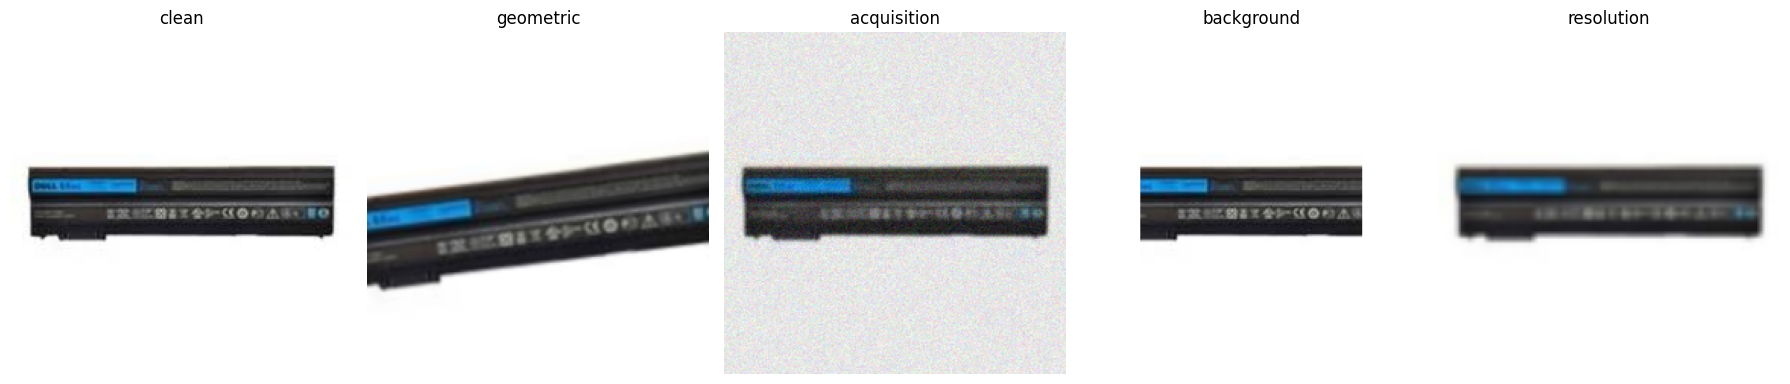

In [ ]:
sample_fp = df_val.iloc[0]['filepath']
sample = Image.open(DATASET_DIR / sample_fp).convert('RGB')
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
axes[0].imshow(sample); axes[0].set_title('clean'); axes[0].axis('off')
for ax, fam in zip(axes[1:], FAMILIES):
    ax.imshow(PERTURB[fam](sample, 0, 'moderate')); ax.set_title(fam); ax.axis('off')
plt.tight_layout(); plt.show()

## 4. Caricamento modello e valutazione

In [ ]:
def load_resnet18(weights_path):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    state = torch.load(weights_path, map_location='cpu')
    if isinstance(state, dict) and 'state_dict' in state:
        state = state['state_dict']
    model.load_state_dict(state)
    return model.to(device).eval()

class ValDataset(Dataset):
    def __init__(self, df, family=None, intensity=None):
        self.items = list(zip(df['filepath'].tolist(), df['label'].tolist()))
        self.family, self.intensity = family, intensity
    def __len__(self):
        return len(self.items)
    def __getitem__(self, i):
        fp, lab = self.items[i]
        img = Image.open(DATASET_DIR / fp).convert('RGB')
        if self.family is not None:
            img = PERTURB[self.family](img, i, self.intensity)
        return preprocess(img), lab

@torch.no_grad()
def evaluate(model, df, family=None, intensity=None):
    dl = DataLoader(ValDataset(df, family, intensity), batch_size=BATCH_SIZE,
                    shuffle=False, num_workers=2)
    ys, ps = [], []
    desc = 'clean' if family is None else f'{family}/{intensity}'
    for x, y in tqdm(dl, desc=desc, leave=False):
        out = model(x.to(device))
        ps.append(out.argmax(1).cpu().numpy()); ys.append(np.asarray(y))
    y = np.concatenate(ys); p = np.concatenate(ps)
    bal = balanced_accuracy_score(y, p)
    tpr = recall_score(y, p, labels=list(range(NUM_CLASSES)), average=None, zero_division=0)
    return bal, dict(zip(CLASS_NAMES, tpr))

## 5. Esecuzione

Riusa i pesi gia salvati. Nessun training.

In [ ]:
rows = []
clean_scores = {}

for recipe, fname in RECIPES.items():
    wpath = MODELS_DIR / fname
    if not wpath.exists():
        print(f"[skip] pesi mancanti per '{recipe}': {wpath}")
        continue
    print(f"\n=== {recipe} ({fname}) ===")
    model = load_resnet18(wpath)

    bal_clean, tpr_clean = evaluate(model, df_val, None, None)
    clean_scores[recipe] = bal_clean
    print(f"  clean-val balAcc = {bal_clean:.4f}")

    for fam in FAMILIES:
        for inten in INTENSITIES:
            bal, tpr = evaluate(model, df_val, fam, inten)
            rows.append({
                'recipe': recipe, 'family': fam, 'intensity': inten,
                'balacc': round(bal, 4),
                **{f'tpr_{c}': round(tpr[c], 4) for c in TARGET_CLASSES},
            })
            print(f"  {fam:11s} {inten:8s} balAcc = {bal:.4f}  "
                  + "  ".join(f"{c}={tpr[c]:.3f}" for c in TARGET_CLASSES))
    del model
    torch.cuda.empty_cache()

long_df = pd.DataFrame(rows)
long_df.to_csv(RESULTS_DIR / 'brief_matched_long.csv', index=False)
print('\nSalvato:', RESULTS_DIR / 'brief_matched_long.csv')


=== baseline (CE) (resnet18_baseline.pth) ===


clean:   0%|          | 0/49 [00:00<?, ?it/s]

  clean-val balAcc = 0.9666


geometric/mild:   0%|          | 0/49 [00:00<?, ?it/s]

  geometric   mild     balAcc = 0.9608  metal=0.948  plastic=0.884


...

resolution/mild:   0%|          | 0/49 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79ea1dedb7e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
Exception ignored in:   <function _MultiProcessingDataLoaderIter.__del__ at 0x79ea1dedb7e0>  
 Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
 ^    self._shutdown_workers()
^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    ^if w.is_alive():^
^ ^ ^ ^ ^^ ^ 
 ^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^^
^  ^ ^^ ^ ^ ^
    File "/usr/li

  resolution  mild     balAcc = 0.9550  metal=0.935  plastic=0.873


resolution/moderate:   0%|          | 0/49 [00:00<?, ?it/s]

  resolution  moderate balAcc = 0.9335  metal=0.890  plastic=0.844

Salvato: /content/drive/MyDrive/2026_MLinf_gr41/Waste-Project/results/brief_matched_long.csv


## 6. Tabelle riassuntive per intensità


In [ ]:
def pivot_for(intensity):
    sub = long_df[long_df['intensity'] == intensity]
    piv = sub.pivot(index='recipe', columns='family', values='balacc')
    piv.insert(0, 'clean', pd.Series(clean_scores))
    piv = piv[['clean'] + FAMILIES]
    piv = piv.sort_values('acquisition', ascending=False)
    return piv

for inten in INTENSITIES:
    piv = pivot_for(inten)
    out = RESULTS_DIR / f'brief_matched_families_{inten}.csv'
    piv.to_csv(out)
    print(f"\n### Intensita: {inten}  (ordinata per 'acquisition')")
    print(piv.round(4).to_string())
    print('Salvato:', out)


### Intensita: mild  (ordinata per 'acquisition')
family                clean  geometric  acquisition  background  resolution
recipe                                                                     
acq_mild_erase       0.9645     0.9598       0.9660      0.9279      0.9564
acq_mild             0.9652     0.9609       0.9656      0.9258      0.9625
acq_mild_weighted    0.9638     0.9582       0.9607      0.8943      0.9550
baseline (CE)        0.9666     0.9608       0.9538      0.9207      0.9468
light                0.9679     0.9601       0.9531      0.9301      0.9463
weighted_loss        0.9606     0.9611       0.9519      0.8942      0.9452
sampler              0.9619     0.9571       0.9504      0.9081      0.9407
geo_rrc (light+RRC)  0.9574     0.9571       0.9426      0.8952      0.9364
strong               0.9540     0.9460       0.9395      0.9225      0.9484
geo_rrc+cutmix       0.9649     0.9639       0.9291      0.9487      0.9379
Salvato: /content/drive/MyDrive/2026_

## 7. Regola di selezione


In [ ]:
NOISE = 0.01

agg = (long_df.groupby(['recipe', 'family'])['balacc'].mean()
       .unstack('family')[FAMILIES])
agg.insert(0, 'clean', pd.Series(clean_scores))
agg['all_families_mean'] = agg[FAMILIES].mean(axis=1)

# Due classifiche affiancate: primario vs. media-su-tutti-gli-assi
rank_acq = agg['acquisition'].rank(ascending=False, method='min').astype(int)
rank_all = agg['all_families_mean'].rank(ascending=False, method='min').astype(int)
compare = pd.DataFrame({
    'acquisition'     : agg['acquisition'].round(4),
    'rank_acquisition': rank_acq,
    'all_families'    : agg['all_families_mean'].round(4),
    'rank_all_axes'   : rank_all,
}).sort_values('rank_acquisition')
print("Due classifiche affiancate (primario 'acquisition' vs media-su-tutti-gli-assi):\n")
print(compare.to_string())

top_acq = compare.sort_values('rank_acquisition').index[0]
top_all = compare.sort_values('rank_all_axes').index[0]
print(f"\nMigliore su 'acquisition'        : {top_acq}")
print(f"Migliore su media tutti gli assi : {top_all}")
print("I due criteri " + ("CONCORDANO."
      if top_acq == top_all else
      "DISCORDANO -> si decide col primario + pavimento (vedi sotto), a occhi aperti."))

# Pavimento di robustezza: non ultima su nessuna famiglia
family_min = agg[FAMILIES].min()                                                # peggior valore per famiglia, tra tutte le ricette
floor_ok   = (agg[FAMILIES] > family_min).all(axis=1)

clean_best = agg['clean'].max()
sanity_ok  = agg['clean'] >= clean_best - NOISE

eligible = agg[floor_ok & sanity_ok].copy()

failed_floor  = agg.index[~floor_ok].tolist()
failed_sanity = agg.index[~sanity_ok].tolist()
if failed_floor:
    print(f"\nEscluse dal pavimento (ultime su qualche asse) : {', '.join(failed_floor)}")
if failed_sanity:
    print(f"Escluse dalla sanity clean (< {clean_best - NOISE:.4f})   : {', '.join(failed_sanity)}")

if len(eligible) == 0:
    print("\n[attenzione] nessuna ricetta supera pavimento+sanity: rilasso il pavimento.")
    eligible = agg[sanity_ok].copy()

ranked = eligible.sort_values(['acquisition', 'all_families_mean'], ascending=False)
winner = ranked.index[0]

print("\nCandidati ammissibili (pavimento + sanity):", ", ".join(ranked.index.tolist()))
print(f"\n>>> RICETTA SELEZIONATA (brief-matched): {winner}")
print(f"    acquisition(mean) = {agg.loc[winner,'acquisition']:.4f} | "
      f"clean = {agg.loc[winner,'clean']:.4f} | "
      f"all-axes = {agg.loc[winner,'all_families_mean']:.4f}")

# Salvataggi
agg_out = agg.sort_values('acquisition', ascending=False)
agg_out.round(4).to_csv(RESULTS_DIR / 'brief_matched_selection.csv')
compare.to_csv(RESULTS_DIR / 'brief_matched_rankings.csv')
print('\nSalvati:', RESULTS_DIR / 'brief_matched_selection.csv', '|',
      RESULTS_DIR / 'brief_matched_rankings.csv')
print(f"Pesi del modello selezionato: {RECIPES.get(winner, '??')}")

Due classifiche affiancate (primario 'acquisition' vs media-su-tutti-gli-assi):

                     acquisition  rank_acquisition  all_families  rank_all_axes
recipe                                                                         
acq_mild                  0.9560                 1        0.9347              1
acq_mild_erase            0.9508                 2        0.9314              2
acq_mild_weighted         0.9476                 3        0.9192              7
light                     0.9202                 4        0.9242              3
strong                    0.9172                 5        0.9209              5
baseline (CE)             0.9127                 6        0.9236              4
weighted_loss             0.9124                 7        0.9101              9
sampler                   0.9090                 8        0.9115              8
geo_rrc (light+RRC)       0.8928                 9        0.9011             10
geo_rrc+cutmix            0.8710       

## 8. Grafico: clean vs famiglie (per ogni ricetta)


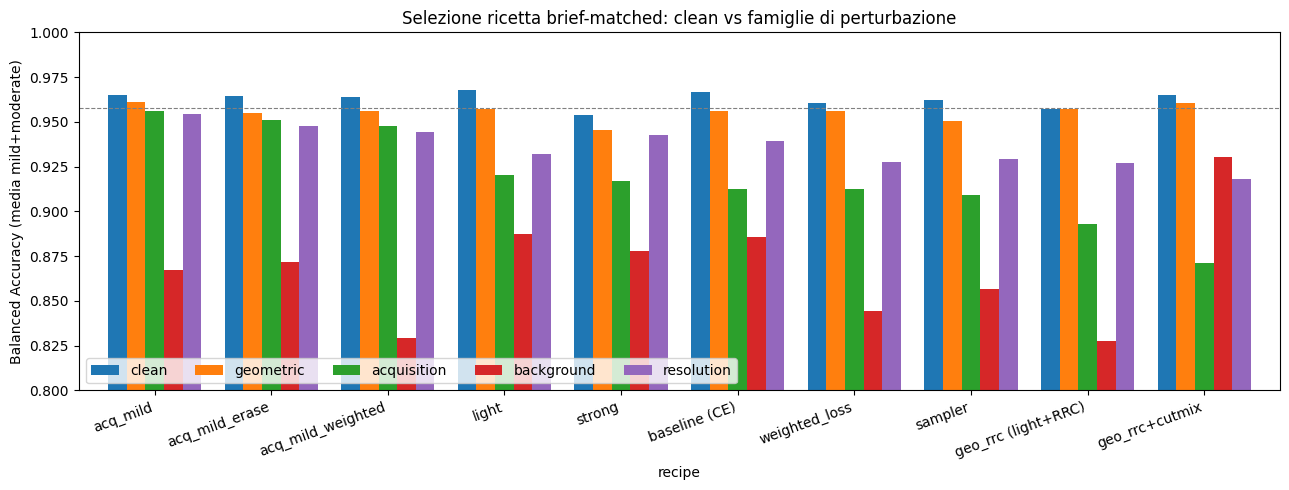

Salvato: /content/drive/MyDrive/2026_MLinf_gr41/Waste-Project/results/brief_matched_recipe_selection.png


In [ ]:
piv = agg[['clean'] + FAMILIES].sort_values('acquisition', ascending=False)
ax = piv.plot(kind='bar', figsize=(13, 5), width=0.8)
ax.set_ylabel('Balanced Accuracy (media mild+moderate)')
ax.set_title('Selezione ricetta brief-matched: clean vs famiglie di perturbazione')
ax.set_ylim(0.80, 1.0)
ax.legend(loc='lower left', ncol=5)
ax.axhline(piv['clean'].max() - 0.01, ls='--', lw=0.8, color='gray')
plt.xticks(rotation=20, ha='right'); plt.tight_layout()
plt.savefig(RESULTS_DIR / 'brief_matched_recipe_selection.png', dpi=120, bbox_inches='tight')
plt.show()
print('Salvato:', RESULTS_DIR / 'brief_matched_recipe_selection.png')